# Ejercicio 12: Multimodal Embeddings 

**Objetivo:** Observar cómo un modelo multimodal como CLIP ubica texto e imágenes en un mismo espacio vectorial, usando un corpus (fotografías de Kaggle) para evidenciar la complejidad real del problema: ambigüedad visual entre clases, variabilidad dentro de una misma clase y una precisión de emparejamiento imperfecta.

## Pasos

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D con PCA y graficarlos en un plano.
4. Verificar emparejamientos usando similitud coseno (texto→imagen e imagen→texto), a nivel exacto y a nivel de clase.

## Parte 1. Dataset real (Kaggle)

Se usa una muestra del dataset real **Multi-class Weather Dataset** (Kaggle, autor `pratik2901`): https://www.kaggle.com/datasets/pratik2901/multiclass-weather-dataset

Contiene fotografías reales de 4 condiciones climáticas: `cloudy`, `rain`, `shine`, `sunrise`. 

In [1]:
%pip install -q kagglehub

import kagglehub

# Descarga el dataset (usa cache local; si ya esta descargado, no lo repite)
RUTA_DATOS = kagglehub.dataset_download("pratik2901/multiclass-weather-dataset")

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Librerias para cargar imagenes, calcular embeddings y graficar
import os
import glob
import random
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
import torch
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

c:\Users\Dayana\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
CLASES = ["cloudy", "rain", "shine", "sunrise"]
N_POR_CLASE = 6

# Descripciones variadas por clase (una por imagen, para que cada texto sea unico)
FRASES = {
    "cloudy": [
        "a photo of an overcast sky",
        "a cloudy day with grey skies",
        "thick clouds covering the sky",
        "a gray, cloudy afternoon",
        "heavy cloud cover overhead",
        "a dull cloudy sky",
    ],
    "rain": [
        "a photo of a rainy day",
        "rain falling from the sky",
        "wet streets during a rainstorm",
        "raindrops falling on a rainy day",
        "a stormy, rainy scene",
        "people walking in the rain",
    ],
    "shine": [
        "a photo of a sunny day",
        "clear blue sky with bright sunshine",
        "a bright and sunny afternoon",
        "sunlight shining on a clear day",
        "a sunny day with no clouds",
        "warm sunshine on a clear day",
    ],
    "sunrise": [
        "a photo of a sunrise",
        "the sun rising over the horizon",
        "a colorful sky at sunrise",
        "early morning sunrise light",
        "the sun coming up at dawn",
        "a golden sunrise over the landscape",
    ],
}

# Se muestrea aleatoriamente N_POR_CLASE imagenes de cada clase
random.seed(0)
muestras = []
for clase in CLASES:
    rutas_clase = sorted(glob.glob(os.path.join(RUTA_DATOS, "**", f"{clase}*"), recursive=True))
    rutas_muestreadas = random.sample(rutas_clase, N_POR_CLASE)
    for ruta, frase in zip(rutas_muestreadas, FRASES[clase]):
        etiqueta = f"{clase}_{os.path.basename(ruta)}"
        muestras.append((etiqueta, ruta, clase, frase))

etiquetas = [m[0] for m in muestras]
imagenes = [Image.open(m[1]).convert("RGB") for m in muestras]
textos = [m[3] for m in muestras]
clases_muestras = [m[2] for m in muestras]

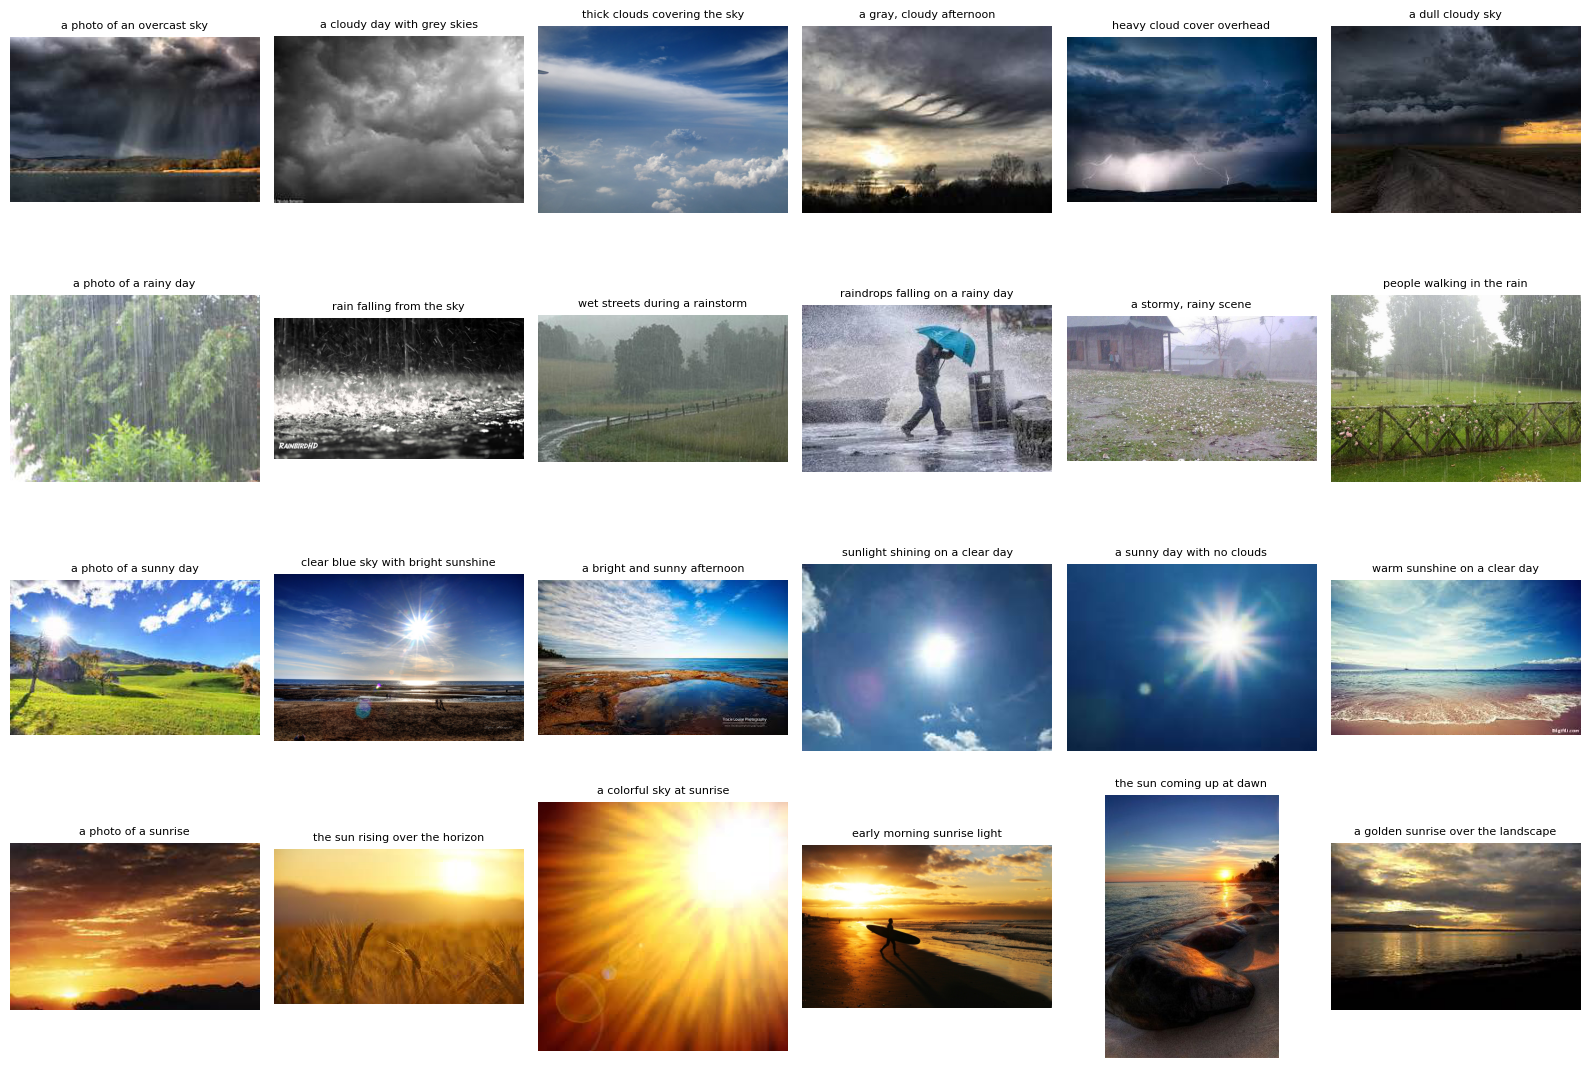

In [4]:
# Se muestran las imagenes cargadas junto con su descripcion textual
figura, ejes = plt.subplots(4, 6, figsize=(16, 11))
for eje, imagen, texto in zip(ejes.flat, imagenes, textos):
    eje.imshow(imagen)
    eje.set_title(texto, fontsize=8)
    eje.axis("off")
plt.tight_layout()
plt.show()

## Parte 2. Embeddings con CLIP

Se carga el modelo preentrenado `openai/clip-vit-base-patch32` y se calculan los embeddings de las imágenes y de los textos. CLIP proyecta ambas modalidades al mismo espacio vectorial, por lo que los vectores resultantes son directamente comparables.

In [5]:
# Carga el modelo CLIP preentrenado y su procesador de entrada
modelo_clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
procesador_clip = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
modelo_clip.eval()

entradas = procesador_clip(text=textos, images=imagenes, return_tensors="pt", padding=True)

# El modelo devuelve un embedding por imagen y otro por texto en el mismo forward
with torch.no_grad():
    salida = modelo_clip(**entradas)
    embeddings_imagen = salida.image_embeds
    embeddings_texto = salida.text_embeds

# Se normalizan los vectores para que el producto punto equivalga a similitud coseno
embeddings_imagen = embeddings_imagen / embeddings_imagen.norm(dim=-1, keepdim=True)
embeddings_texto = embeddings_texto / embeddings_texto.norm(dim=-1, keepdim=True)

print("Forma embeddings de imagen:", tuple(embeddings_imagen.shape))
print("Forma embeddings de texto:", tuple(embeddings_texto.shape))

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Forma embeddings de imagen: (24, 512)
Forma embeddings de texto: (24, 512)


## Parte 3. Mismo espacio vectorial

Ambos tipos de embedding tienen la misma dimensión y, al estar normalizados, la misma norma. Esto confirma que texto e imagen conviven en el mismo espacio y pueden compararse directamente.

In [6]:
# Se comprueba que ambas modalidades comparten dimension y norma
print("Dimension embeddings de imagen:", embeddings_imagen.shape[1])
print("Dimension embeddings de texto:", embeddings_texto.shape[1])
print("Norma promedio embeddings de imagen:", embeddings_imagen.norm(dim=-1).mean().item())
print("Norma promedio embeddings de texto:", embeddings_texto.norm(dim=-1).mean().item())

Dimension embeddings de imagen: 512
Dimension embeddings de texto: 512
Norma promedio embeddings de imagen: 1.0
Norma promedio embeddings de texto: 1.0


## Parte 4. Proyección a 2D con PCA

Se combinan los embeddings de imagen y texto en una sola matriz y se reduce su dimensionalidad a 2D con PCA. Como existen 4 clases climáticas, se colorea cada punto segun su clase (el marcador indica la modalidad: circulo = imagen, triangulo = texto). Si las clases se superponen en el plano, es una primera señal de que CLIP las encuentra visualmente ambiguas.

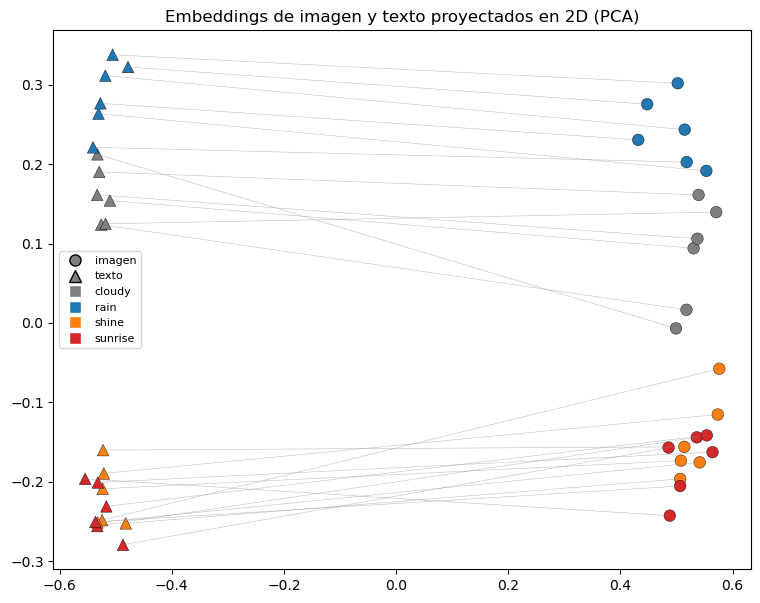

In [7]:
# Se concatenan ambas modalidades antes de proyectar para que compartan el mismo plano 2D
embeddings_todos = np.vstack([embeddings_imagen.numpy(), embeddings_texto.numpy()])
proyeccion_2d = PCA(n_components=2, random_state=0).fit_transform(embeddings_todos)

n_muestras = len(muestras)
puntos_imagen = proyeccion_2d[:n_muestras]
puntos_texto = proyeccion_2d[n_muestras:]

# Color por clase climatica, marcador por modalidad
color_por_clase = {"cloudy": "tab:gray", "rain": "tab:blue", "shine": "tab:orange", "sunrise": "tab:red"}
colores = [color_por_clase[c] for c in clases_muestras]

plt.figure(figsize=(9, 7))
plt.scatter(puntos_imagen[:, 0], puntos_imagen[:, 1], c=colores, marker="o", edgecolors="black", linewidths=0.3, s=70)
plt.scatter(puntos_texto[:, 0], puntos_texto[:, 1], c=colores, marker="^", edgecolors="black", linewidths=0.3, s=70)

# Se traza una linea entre cada imagen y su texto correspondiente
for i in range(n_muestras):
    plt.plot(
        [puntos_imagen[i, 0], puntos_texto[i, 0]],
        [puntos_imagen[i, 1], puntos_texto[i, 1]],
        color="gray", linewidth=0.4, alpha=0.5,
    )

leyenda = [Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markeredgecolor="black", label="imagen", markersize=8),
           Line2D([0], [0], marker="^", color="w", markerfacecolor="gray", markeredgecolor="black", label="texto", markersize=8)]
leyenda += [Line2D([0], [0], marker="s", color="w", markerfacecolor=color, label=clase, markersize=8) for clase, color in color_por_clase.items()]
plt.legend(handles=leyenda, fontsize=8, loc="best")
plt.title("Embeddings de imagen y texto proyectados en 2D (PCA)")
plt.show()

## Parte 5. Emparejamiento con similitud coseno

Se calcula la similitud coseno entre cada texto y cada imagen, y se realiza la búsqueda en ambas direcciones: texto→imagen e imagen→texto. Como los embeddings ya están normalizados, la similitud coseno equivale al producto punto.

- **Acierto exacto:** el texto encontro precisamente su imagen original.
- **Acierto de clase:** el texto encontro *alguna* imagen de su misma clase climatica (una respuesta semanticamente correcta aunque no sea la imagen exacta).

In [8]:
# Matriz de similitud: cada fila es un texto, cada columna una imagen
similitud = embeddings_texto @ embeddings_imagen.T

# Para cada texto se busca la imagen mas similar, y viceversa
indice_texto_a_imagen = similitud.argmax(dim=1)
indice_imagen_a_texto = similitud.T.argmax(dim=1)

indices_correctos = torch.arange(n_muestras)
aciertos_t2i = indice_texto_a_imagen == indices_correctos
aciertos_i2t = indice_imagen_a_texto == indices_correctos

# Acierto a nivel de clase climatica (ver Parte 5)
clases_pred_t2i = [clases_muestras[i] for i in indice_texto_a_imagen]
clases_pred_i2t = [clases_muestras[i] for i in indice_imagen_a_texto]
aciertos_t2i_clase = [pred == real for pred, real in zip(clases_pred_t2i, clases_muestras)]
aciertos_i2t_clase = [pred == real for pred, real in zip(clases_pred_i2t, clases_muestras)]

In [9]:
# Busqueda texto -> imagen
resultados_t2i = pd.DataFrame({
    "texto": textos,
    "clase_real": clases_muestras,
    "imagen_predicha": [etiquetas[i] for i in indice_texto_a_imagen],
    "clase_predicha": clases_pred_t2i,
    "acierto_exacto": aciertos_t2i.numpy(),
    "acierto_clase": aciertos_t2i_clase,
})
resultados_t2i

,texto,clase_real,imagen_predicha,clase_predicha,acierto_exacto,acierto_clase
0,a photo of an overcast sky,cloudy,cloudy_cloudy292.jpg,cloudy,False,True
1,a cloudy day with grey skies,cloudy,cloudy_cloudy292.jpg,cloudy,True,True
2,thick clouds covering the sky,cloudy,cloudy_cloudy292.jpg,cloudy,False,True
3,"a gray, cloudy afternoon",cloudy,cloudy_cloudy292.jpg,cloudy,False,True
4,heavy cloud cover overhead,cloudy,cloudy_cloudy292.jpg,cloudy,False,True
5,a dull cloudy sky,cloudy,cloudy_cloudy292.jpg,cloudy,False,True
6,a photo of a rainy day,rain,rain_rain180.jpg,rain,False,True
7,rain falling from the sky,rain,rain_rain191.jpg,rain,False,True
8,wet streets during a rainstorm,rain,rain_rain85.jpg,rain,False,True
9,raindrops falling on a rainy day,rain,rain_rain85.jpg,rain,False,True


In [10]:
# Busqueda imagen -> texto
resultados_i2t = pd.DataFrame({
    "imagen": etiquetas,
    "clase_real": clases_muestras,
    "texto_predicho": [textos[i] for i in indice_imagen_a_texto],
    "clase_predicha": clases_pred_i2t,
    "acierto_exacto": aciertos_i2t.numpy(),
    "acierto_clase": aciertos_i2t_clase,
})
resultados_i2t

,imagen,clase_real,texto_predicho,clase_predicha,acierto_exacto,acierto_clase
0,cloudy_cloudy276.jpg,cloudy,"a stormy, rainy scene",rain,False,False
1,cloudy_cloudy292.jpg,cloudy,a photo of an overcast sky,cloudy,False,True
2,cloudy_cloudy116.jpg,cloudy,heavy cloud cover overhead,cloudy,False,True
3,cloudy_cloudy217.jpg,cloudy,a photo of an overcast sky,cloudy,False,True
4,cloudy_cloudy63.jpg,cloudy,"a stormy, rainy scene",rain,False,False
5,cloudy_cloudy51.jpg,cloudy,"a stormy, rainy scene",rain,False,False
6,rain_rain191.jpg,rain,a photo of a rainy day,rain,True,True
7,rain_rain85.jpg,rain,a photo of a rainy day,rain,False,True
8,rain_rain96.jpg,rain,"a stormy, rainy scene",rain,False,True
9,rain_rain168.jpg,rain,people walking in the rain,rain,False,True


In [11]:
# Precision de cada direccion de busqueda, a nivel exacto y a nivel de clase
print(f"Precision texto->imagen (imagen exacta):        {aciertos_t2i.float().mean().item():.2f}")
print(f"Precision texto->imagen (clase climatica):       {np.mean(aciertos_t2i_clase):.2f}")
print(f"Precision imagen->texto (texto exacto):          {aciertos_i2t.float().mean().item():.2f}")
print(f"Precision imagen->texto (clase climatica):       {np.mean(aciertos_i2t_clase):.2f}")

Precision texto->imagen (imagen exacta):        0.08
Precision texto->imagen (clase climatica):       0.88
Precision imagen->texto (texto exacto):          0.12
Precision imagen->texto (clase climatica):       0.83


## Interpretación


- La **precisión exacta** suele bajar, porque varias imágenes de una misma clase comparten casi la misma descripción y CLIP puede confundir una foto `cloudy` con otra `cloudy` distinta.
- La **precisión de clase** suele mantenerse más alta, mostrando que CLIP sigue capturando bien el concepto climático general aunque no identifique la foto exacta.
- Si hay errores *entre* clases (p. ej. un texto de `shine` que empareja con una imagen `sunrise`, o `cloudy` con `rain`), eso evidencia la ambigüedad visual real entre esas condiciones climáticas.